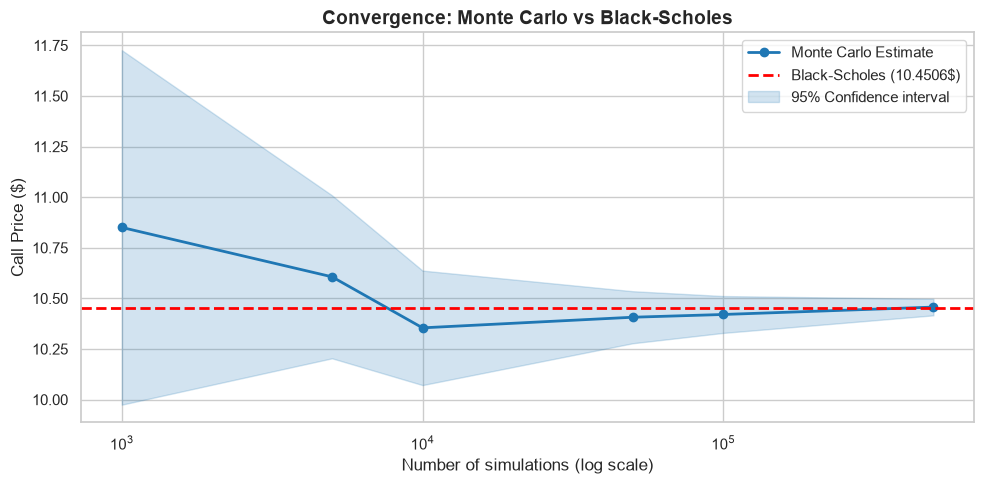

In [20]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from quant_pricing.black_scholes import BlackScholesPricer
from quant_pricing.monte_carlo import MonteCarloPricer

sns.set_theme(style="whitegrid")

# Srt parameters
S0, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20

# 1. Price BS
bs_price = BlackScholesPricer(S0, K, T, r, sigma).price("call")

# 2. Simulations with different N
simulations = [1_000, 5_000, 10_000, 50_000, 100_000, 500_000]
mc_prices, mc_errors = [], []

for N in simulations:
    mc_p, mc_err = MonteCarloPricer(S0, K, T, r, sigma).price(
        "call", num_simulations=N, seed=6767
    )
    mc_prices.append(mc_p)
    mc_errors.append(mc_err)

mc_prices = np.array(mc_prices)
mc_errors = np.array(mc_errors)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(
    simulations,
    mc_prices,
    "o-",
    label="Monte Carlo Estimate",
    color="#1f77b4",
    linewidth=2,
)
plt.axhline(
    bs_price,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Black-Scholes ({bs_price:.4f}$)",
)

# 95% Confidence Interval (+/- 1.96 * SE)
plt.fill_between(
    simulations,
    mc_prices - 1.96 * mc_errors,
    mc_prices + 1.96 * mc_errors,
    color="#1f77b4",
    alpha=0.2,
    label="95% Confidence interval",
)

plt.xscale("log")
plt.title(
    "Convergence: Monte Carlo vs Black-Scholes",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Number of simulations (log scale)", fontsize=12)
plt.ylabel("Call Price ($)", fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

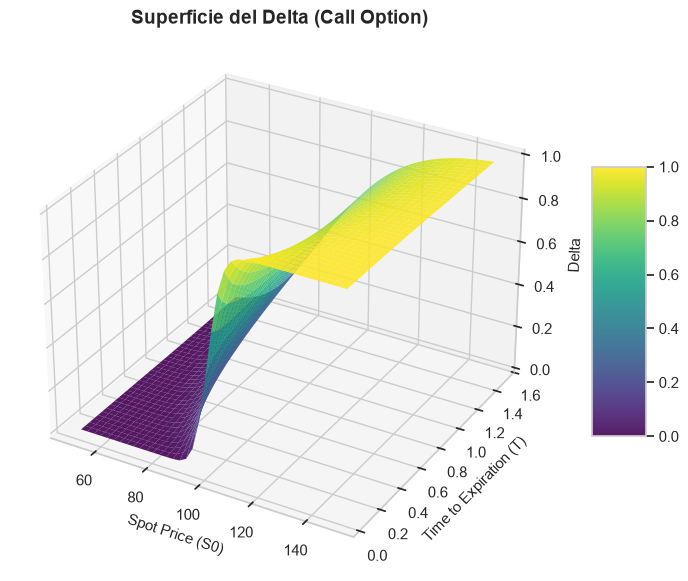

In [ ]:
from matplotlib import cm
from quant_pricing.black_scholes import BlackScholesPricer

spot_prices = np.linspace(50, 150, 40)
times_to_exp = np.linspace(0.05, 1.5, 40)
S_grid, T_grid = np.meshgrid(spot_prices, times_to_exp)

delta_grid = np.zeros_like(S_grid)

for i in range(S_grid.shape[0]):
    for j in range(S_grid.shape[1]):
        pricer = BlackScholesPricer(
            S0=S_grid[i, j], K=100.0, T=T_grid[i, j], r=0.05, sigma=0.20
        )
        delta_grid[i, j] = pricer.delta(option_type="call")

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(
    S_grid, T_grid, delta_grid, cmap=cm.viridis, edgecolor="none", alpha=0.9
)

ax.set_title(
    "Delta Surface (Call Option)", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Spot Price (S0)", fontsize=11)
ax.set_ylabel("Time to Expiration (T)", fontsize=11)
ax.set_zlabel("Delta", fontsize=11)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

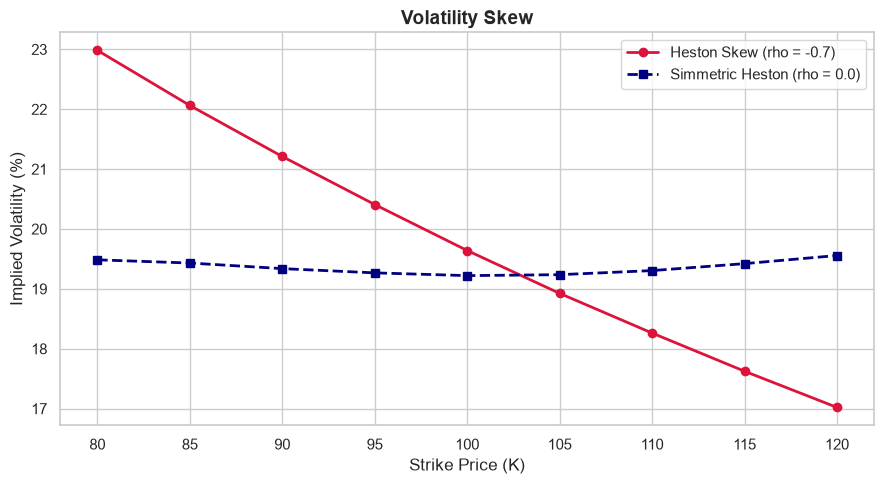

In [29]:
from quant_pricing.heston import HestonMonteCarloPricer
from quant_pricing.implied_volatility import implied_volatility

strikes = np.linspace(80, 120, 9)
S0, T, r, v0 = 100.0, 1.0, 0.03, 0.04

iv_skew = []
iv_flat = []

# 1. Heston with Negative Correlation (rho = -0.7) -> Skew
for K in strikes:
    p_h, _ = HestonMonteCarloPricer(
        S0, K, T, r, v0=v0, kappa=2.0, theta=0.04, xi=0.3, rho=-0.7
    ).price("call", num_simulations=50_000, seed=6767)
    iv = implied_volatility(
        market_price=p_h, S0=S0, K=K, T=T, r=r, option_type="call"
    )
    iv_skew.append(iv)

# 2. Heston with No Correlation (rho = 0.0)
for K in strikes:
    p_h, _ = HestonMonteCarloPricer(
        S0, K, T, r, v0=v0, kappa=2.0, theta=0.04, xi=0.3, rho=0.0
    ).price("call", num_simulations=50_000, seed=6767)
    iv = implied_volatility(
        market_price=p_h, S0=S0, K=K, T=T, r=r, option_type="call"
    )
    iv_flat.append(iv)

plt.figure(figsize=(9, 5))
plt.plot(
    strikes,
    np.array(iv_skew) * 100,
    "o-",
    color="crimson",
    linewidth=2,
    label="Heston Skew (rho = -0.7)",
)
plt.plot(
    strikes,
    np.array(iv_flat) * 100,
    "s--",
    color="navy",
    linewidth=2,
    label="Simmetric Heston (rho = 0.0)",
)

plt.title(
    "Volatility Skew", fontsize=14, fontweight="bold"
)
plt.xlabel("Strike Price (K)", fontsize=12)
plt.ylabel("Implied Volatility (%)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

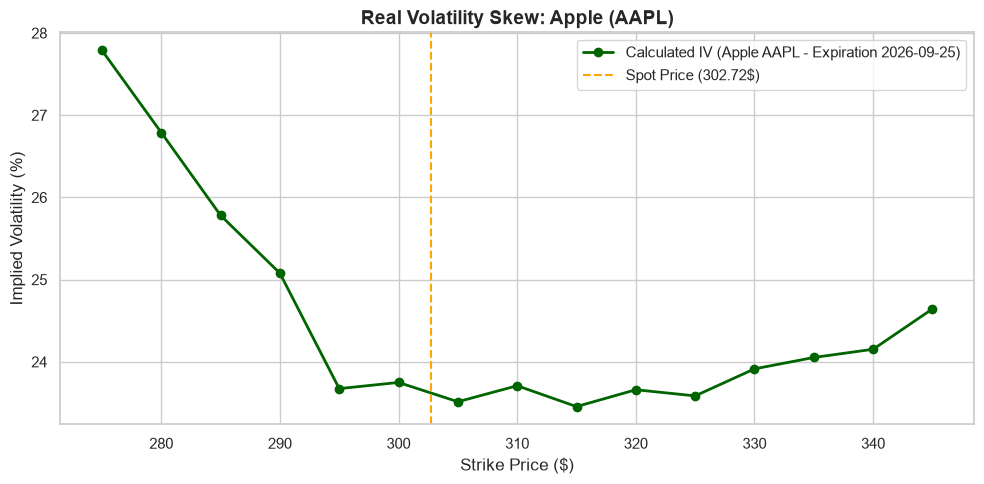

In [28]:
from datetime import datetime
import pandas as pd
import yfinance as yf

# 1. Ticker: AAPL
ticker = yf.Ticker("AAPL")
S0_real = ticker.history(period="1d")["Close"].iloc[-1]

# Choose an option
expirations = ticker.options
target_exp = expirations[9]  # Tenth expiration date 

# Time-to-Expiration T in years
exp_date = datetime.strptime(target_exp, "%Y-%m-%d")
days_to_exp = (exp_date - datetime.now()).days
T_real = days_to_exp / 365.0

# 2. Extract Call Chain
opt_chain = ticker.option_chain(target_exp).calls

# Options near the Spot price (es. +/- 15%)
opt_chain = opt_chain[
    (opt_chain["strike"] >= S0_real * 0.85)
    & (opt_chain["strike"] <= S0_real * 1.15)
]

# Mid Price
opt_chain["mid_price"] = (opt_chain["bid"] + opt_chain["ask"]) / 2.0

# 3. IV
r_real = 0.045  # US Interest Rate ~4.5%
calc_ivs = []

for idx, row in opt_chain.iterrows():
    iv = implied_volatility(
        market_price=row["mid_price"],
        S0=S0_real,
        K=row["strike"],
        T=T_real,
        r=r_real,
        option_type="call",
    )
    calc_ivs.append(iv)

opt_chain["our_calculated_iv"] = calc_ivs

# 4. Grafico del Volatility Smile Reale di Apple
plt.figure(figsize=(10, 5))
plt.plot(
    opt_chain["strike"],
    opt_chain["our_calculated_iv"] * 100,
    "o-",
    color="darkgreen",
    linewidth=2,
    label=f"Calculated IV (Apple AAPL - Expiration {target_exp})",
)
plt.axvline(
    S0_real,
    color="orange",
    linestyle="--",
    label=f"Spot Price ({S0_real:.2f}$)",
)

plt.title(
    f"Real Volatility Skew: Apple (AAPL)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Strike Price ($)", fontsize=12)
plt.ylabel("Implied Volatility (%)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()